In [15]:
import numpy as np
import pandas as pd
from scipy.optimize import newton
import emcee
import matplotlib.pyplot as plt
import corner

# Load the data which you just simulated
from data_loader import S2DataLoader
import tqdm

# Load S2 Data

           t         x     x_err         y     y_err
0  2002.2503  0.008122  0.002810 -0.014417  0.002810
1  2002.3351 -0.003988  0.001887 -0.009717  0.001887
2  2002.3927 -0.013654  0.002662 -0.002115  0.002662
           t      vz  vz_err
0  2003.3532 -1512.0    35.0
1  2003.4463 -1428.0    45.0
0  2000.4870  1199.0   100.0


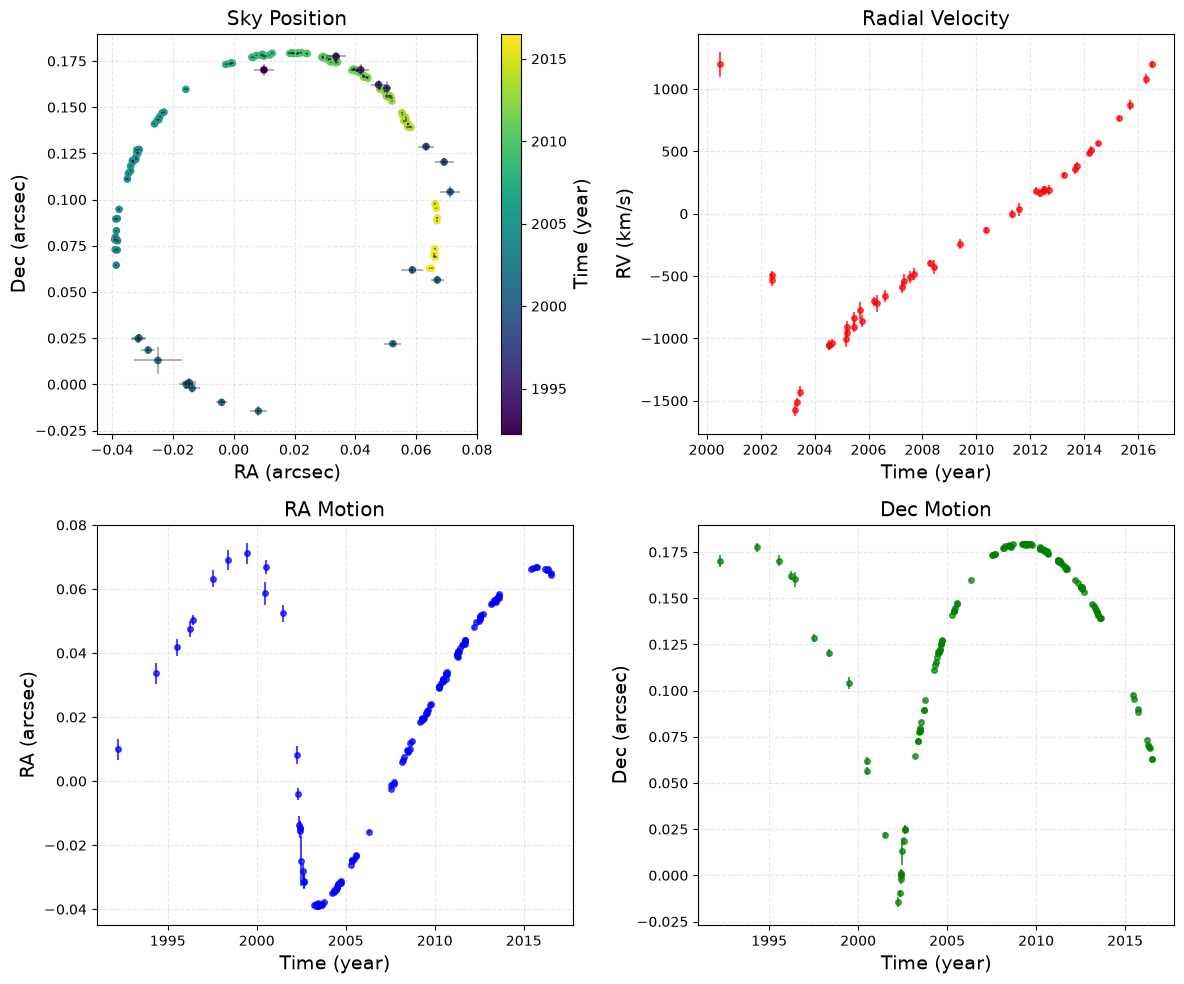

In [16]:
# Load real S2 data
s2_data = S2DataLoader()
astro_df, vel_df = s2_data.load_data()
print(astro_df.head(3))
print(vel_df.head(3))

# Plot S2 data
fig = s2_data.plot_all()
fig.savefig('s2_data.pdf')
plt.show()

In [17]:
data = s2_data.get_data()
t_ast = data['t_ast']
RA_obs = data['ra_obs']
Dec_obs = data['dec_obs']
sigma_RA = data['ra_err']
sigma_Dec = data['dec_err']
t_rv = data['t_rv']
RV_obs = data['rv_obs']  # km/s
sigma_RV = data['rv_err']  # km/s

In [18]:
t_obs = np.concatenate([data['t_ast'], data['t_rv']])

# The Model

In [19]:
import numpy as np
from scipy.integrate import solve_ivp

def mond_orbit_equations(t, y, G, M, a0):
    """MOND EOM in the orbital plane (2D). From the attached mond_orbit.py."""
    x, y_pos, vx, vy = y
    r = np.sqrt(x**2 + y_pos**2)
    if r < 1e-8:
        return [0.0, 0.0, 0.0, 0.0]
    
    a_N = (G * M) / r**2
    # Standard MOND simple interpolating function
    a_MOND = (a_N + np.sqrt(a_N**2 + 4 * a_N * a0)) / 2
    
    ax = -a_MOND * (x / r)
    ay = -a_MOND * (y_pos / r)
    return [vx, vy, ax, ay]


def orbit_model_mond(t, theta,G=1):
    """
    MOND orbit model with full 3D position + velocity projection.
    
    Parameters
    ----------
    t : array-like
        Observation times (same array for positions and RVs).
    theta : array
        [a, e, i_deg, omega_deg, Omega_deg, T0, Mtot, a0]
    RA_obs_len, Dec_obs_len : int (optional)
        Number of astrometric observations for slicing.
    
    Returns
    -------
    RA_model, Dec_model, RV_model : np.arrays
        Exactly matching the calling convention of your original model.
    """
    a, e, i_deg, omega_deg, Omega_deg, T0, Mtot, a0 = theta
    
    i = np.radians(i_deg)
    omega = np.radians(omega_deg)
    Omega = np.radians(Omega_deg)
    
    # Safety checks
    if e >= 1.0 or a <= 0 or Mtot <= 0 or a0 < 0:
        n = len(t)
        return np.zeros(n), np.zeros(n), np.zeros(n)
    
    # 1. Initial conditions at pericenter (t = T0)
    r_peri = a * (1 - e)
    v_peri = np.sqrt(G * Mtot * (1 + e) / (a * (1 - e)))  # Newtonian vis-viva at pericenter
    
    y0 = [r_peri, 0.0, 0.0, v_peri]   # [x, y, vx, vy] in orbital plane
    
    # 2. Integrate over relative times
    t_rel = np.asarray(t) - T0
    unique_t_rel, inv_idx = np.unique(t_rel, return_inverse=True)
    t_span = (unique_t_rel.min() - 0.1, unique_t_rel.max() + 0.1)
    
    sol = solve_ivp(
        mond_orbit_equations,
        t_span,
        y0,
        args=(G, Mtot, a0),
        t_eval=np.sort(unique_t_rel),
        method='DOP853',      # High accuracy Runge-Kutta
        rtol=1e-10,
        atol=1e-10,
        dense_output=False
    )
    
    if not sol.success:
        n = len(t)
        return np.zeros(n), np.zeros(n), np.zeros(n)
    
    # Get orbital plane solutions for unique times
    x_orb_unique = sol.y[0]
    y_orb_unique = sol.y[1]
    vx_orb_unique = sol.y[2]
    vy_orb_unique = sol.y[3]

    # Map back to original order using inv_idx
    x_orb = x_orb_unique[inv_idx]
    y_orb = y_orb_unique[inv_idx]
    vx_orb = vx_orb_unique[inv_idx]
    vy_orb = vy_orb_unique[inv_idx]

    # 3. Full 3D rotation matrices
    cos_O, sin_O = np.cos(Omega), np.sin(Omega)
    cos_o, sin_o = np.cos(omega), np.sin(omega)
    cos_i, sin_i = np.cos(i), np.sin(i)

    
    RA_model = []
    Dec_model = []
    RV_model = []
    
    for j in range(len(x_orb)):
        x = x_orb[j]
        y = y_orb[j]
        vx_p = vx_orb[j]   # velocity in orbital plane
        vy_p = vy_orb[j]
        
        # Position in sky coordinates (X towards node, Y in sky plane, Z = LOS)
        X = (cos_O * cos_o - sin_O * sin_o * cos_i) * x + \
            (-cos_O * sin_o - sin_O * cos_o * cos_i) * y
        
        Y = (sin_O * cos_o + cos_O * sin_o * cos_i) * x + \
            (-sin_O * sin_o + cos_O * cos_o * cos_i) * y
        
        Z = (sin_o * sin_i) * x + (cos_o * sin_i) * y   # LOS component (not needed for RA/Dec)
        
        RA_model.append(X)
        Dec_model.append(Y)
        
        # Velocity projection onto line-of-sight (Z direction)
        # Rotate velocity vector the same way
        vX = (cos_O * cos_o - sin_O * sin_o * cos_i) * vx_p + \
             (-cos_O * sin_o - sin_O * cos_o * cos_i) * vy_p
        
        vY = (sin_O * cos_o + cos_O * sin_o * cos_i) * vx_p + \
             (-sin_O * sin_o + cos_O * cos_o * cos_i) * vy_p
        
        vZ = (sin_o * sin_i) * vx_p + (cos_o * sin_i) * vy_p   # Radial velocity component
        
        RV_model.append(vZ)
    
    RA_model = np.array(RA_model)
    Dec_model = np.array(Dec_model)
    RV_model = np.array(RV_model)
    
    # Slice exactly as in your original function
    #n_pos = RA_obs_len if RA_obs_len is not None else len(RA_model)
    # return (RA_model[:n_pos], 
    #         Dec_model[:n_pos], 
    #         RV_model[n_pos:])   # RV starts after position data
    n_pos = len(RA_obs)  # Better: use actual length from data, not hardcoded 145
    if n_pos > len(RA_model):
        n_pos = len(RA_model)

    return (RA_model[:n_pos].copy(),
            Dec_model[:n_pos].copy(),
            RV_model[n_pos:].copy())

In [20]:
def log_likelihood(theta):
    try:
        RA_mod, Dec_mod, RV_mod = orbit_model_mond(t_obs, theta)
        # Check shapes
        if len(RA_mod) != len(RA_obs) or len(Dec_mod) != len(Dec_obs) or len(RV_mod) != len(RV_obs):
            return -np.inf
        chi2_RA = np.sum( ((RA_mod - RA_obs) / sigma_RA)**2 )
        chi2_Dec = np.sum( ((Dec_mod - Dec_obs) / sigma_Dec)**2 )
        chi2_RV = np.sum( ((RV_mod - RV_obs) / sigma_RV)**2 )
        return -0.5 * (chi2_RA + chi2_Dec + chi2_RV)
    except Exception as e:
        print("Likelihood error:", e)
        return -np.inf

# Priors - fixed syntax
def log_prior(theta):
    a, e, i, omega, Omega, T0, M, a0 = theta
    if not (0.7 < e < 0.95 and 
            0.5 < a < 3.0 and 
            30 < i < 60 and
            110 < omega < 130 and 
            50 < Omega < 70 and 
            -0.05 < T0 < 0.05 and 
            3.5 < M < 6.0 and 
            0.005 < a0 < 0.2):
        return -np.inf
    return 0.0


def log_posterior(theta):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta)

In [21]:
ndim = 8
nwalkers = 100
nsteps = 2000
nburn = 500
initial = np.array([1.70, 0.803, 44.0, 121.9, 57.1, 0.001, 4.54, 0.030])   
pos = initial + 1e-4 * np.random.randn(nwalkers, ndim)  # Slightly larger spread

sampler = emcee.EnsembleSampler(nwalkers, ndim, log_posterior)

print("Running MCMC...")
sampler.run_mcmc(pos, nsteps, progress=True)

samples = sampler.get_chain(discard=nburn, thin=10, flat=True)

Running MCMC...


100%|██████████████████████████████████████| 2000/2000 [43:06<00:00,  1.29s/it]


## Convergance Plots

In [2]:
import matplotlib.pyplot as plt
# convergence plots

samples_all = sampler.get_chain()  # shape (nsteps, nwalkers, ndim)
param_names = ["a", "e", "i", "omega", "Omega", "T0", "M","a0"]

fig, axes = plt.subplots(ndim, 1, figsize=(10, 2*ndim), sharex=True)
for i in range(ndim):
    ax = axes[i]
    for walker in range(nwalkers):
        ax.plot(samples_all[:, walker, i], alpha=0.3)
    ax.set_ylabel(param_names[i])
axes[-1].set_xlabel("Step number")
plt.suptitle("Trace plots for all parameters")
plt.savefig('converge-mond(nb).pdf')
plt.show()

NameError: name 'sampler' is not defined

In [9]:
# mean and per-walker acceptance fractions
af = sampler.acceptance_fraction
print(f"Mean acceptance fraction: {np.mean(af):.3f}")
print("Acceptance fractions per walker:")
print(af)

Mean acceptance fraction: 0.348
Acceptance fractions per walker:
[0.363 0.356 0.372 0.365 0.36  0.328 0.348 0.341 0.36  0.366 0.362 0.358
 0.337 0.366 0.34  0.351 0.356 0.344 0.292 0.336 0.321 0.324 0.372 0.337
 0.327 0.355 0.366 0.35  0.336 0.372 0.337 0.339 0.357 0.34  0.339 0.383
 0.368 0.372 0.342 0.359 0.367 0.338 0.368 0.329 0.339 0.327 0.352 0.347
 0.335 0.35  0.353 0.348 0.335 0.373 0.346 0.318 0.359 0.327 0.372 0.365
 0.335 0.358 0.344 0.349 0.357 0.348 0.34  0.365 0.336 0.351 0.345 0.342
 0.331 0.349 0.362 0.308 0.333 0.368 0.368 0.302 0.368 0.331 0.363 0.352
 0.363 0.343 0.344 0.32  0.339 0.354 0.366 0.344 0.34  0.357 0.359 0.351
 0.314 0.348 0.339 0.343]


In [10]:
try:
    tau = sampler.get_autocorr_time()
    print("Autocorrelation times (per parameter):")
    for name, t in zip(["a", "e", "i", "omega", "Omega", "T0", "M","a0"], tau):
        print(f"{name:7s} : {t:.1f} steps")
except Exception as e:
    print("Could not compute autocorrelation times yet — chains may be too short.")
    print(e)

Could not compute autocorrelation times yet — chains may be too short.
The chain is shorter than 50 times the integrated autocorrelation time for 8 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 20;
tau: [130.56126432  77.65178148 134.18786485 111.09257734 125.66276628
  51.53257845 114.32857062 100.26863973]


Autocorrelation times: [130.56126432  77.65178148 134.18786485 111.09257734 125.66276628
  51.53257845 114.32857062 100.26863973]


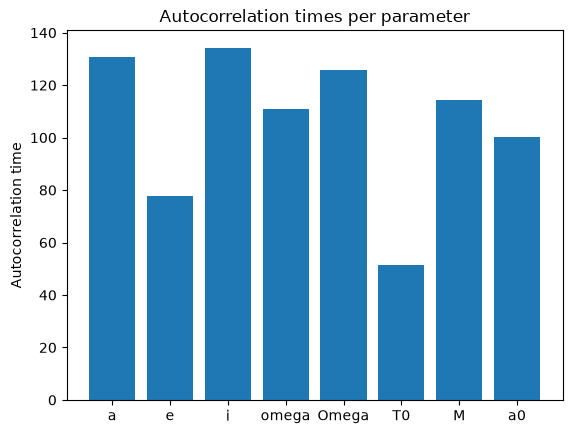

In [11]:
tau = sampler.get_autocorr_time(tol=0)
print("Autocorrelation times:", tau)

fig, ax = plt.subplots()
ax.bar(param_names, tau)
ax.set_ylabel("Autocorrelation time")
ax.set_title("Autocorrelation times per parameter")
plt.show()

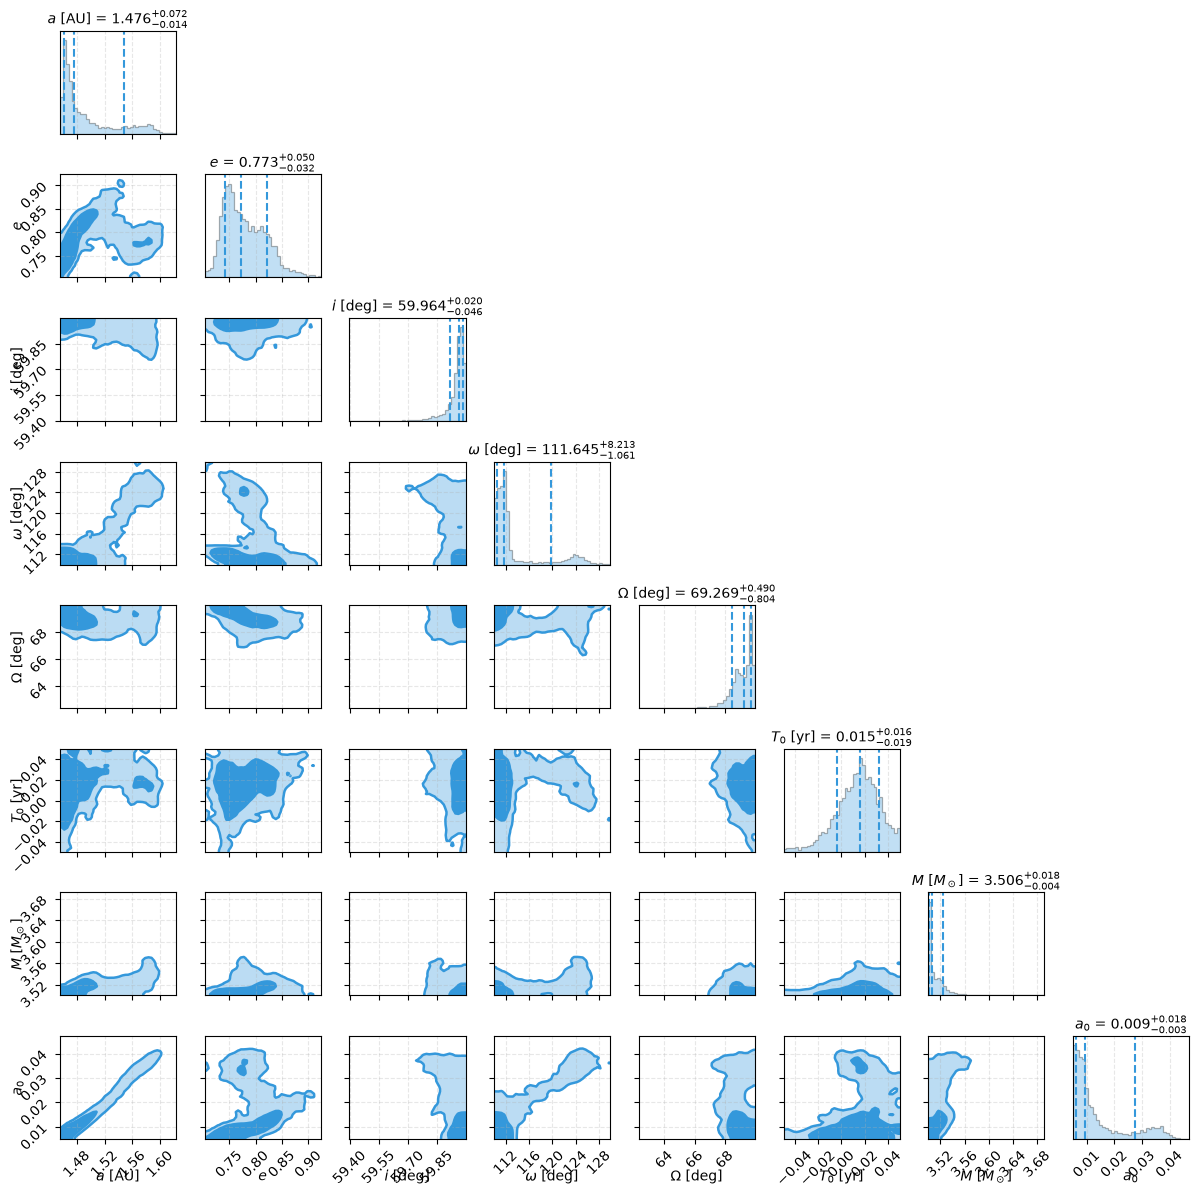

In [14]:
import corner
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# Set up professional styling
mpl.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--'
})

# Burn the first 1000 samples
burn_in = 10000
post_burn_samples = samples[burn_in:]


# Parameter labels with units
labels = [
    r"$a$ [AU]", 
    r"$e$", 
    r"$i$ [deg]", 
    r"$\omega$ [deg]", 
    r"$\Omega$ [deg]", 
    r"$T_0$ [yr]", 
    r"$M$ [$M_\odot$]",
    r"$a_0$"
]

# Create the corner plot with professional settings
fig = corner.corner(
    post_burn_samples,
    labels=labels,
    quantiles=[0.16, 0.5, 0.84],  # Median and ±1σ
    show_titles=True,
    title_fmt='.3f',  # 3 decimal places
    title_kwargs={"fontsize": 10, "pad": 5},
    label_kwargs={"fontsize": 10},
    color="#3498db",  # Professional blue
    smooth=1.0,      # Smoother distributions
    bins=40,         # More bins for better resolution
    plot_datapoints=False,
    fill_contours=True,
    levels=[0.68, 0.95],  # 1σ and 2σ contours
    hist_kwargs={
        "density": True,
        "edgecolor": "k",
        "linewidth": 0.9,
        "histtype": "stepfilled",
        "alpha": 0.3
    },
    contour_kwargs={
        "linewidths": 1.8,
        "linestyles": "solid"
    },
    fig=plt.figure(figsize=(12, 12)))  # Larger figure size

# Adjust layout
plt.tight_layout(pad=0.50)  # Extra padding
plt.savefig('corner-mond2(nb).pdf')
plt.show()